# ISCO to SOC Mapping Comparison

This notebook compares ISCO to SOC mappings across three different crosswalk files:
1. webb_crosswalk_clean.xls
2. ISCO_SOC_Crosswalk.xls  
3. ESCO_to_ONET-SOC.xlsx

The goal is to understand the differences and overlaps between these mapping systems.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

## 1. Load and Examine Webb Crosswalk

In [18]:
# Check if webb_crosswalk_clean.xls exists
webb_path = Path('../Data/webb_crosswalk_clean.xls')
if webb_path.exists():
    try:
        webb_df = pd.read_excel(webb_path)
        print(f"Webb crosswalk loaded successfully. Shape: {webb_df.shape}")
        print("\nColumns:")
        print(webb_df.columns.tolist())
        print("\nFirst few rows:")
        display(webb_df.head())
        print("\nData types:")
        print(webb_df.dtypes)
    except Exception as e:
        print(f"Error loading webb_crosswalk_clean.xls: {e}")
        webb_df = None
else:
    print("webb_crosswalk_clean.xls not found")
    webb_df = None

Webb crosswalk loaded successfully. Shape: (1197, 11)

Columns:
['onet_name', 'onetsoccode', 'agg_pairs', 'ai_score', 'software_score', 'robot_score', 'onet_code_after_point', 'onetsoccode_for_matching', 'isco08', 'isco08_name', 'Comment']

First few rows:


,onet_name,onetsoccode,agg_pairs,ai_score,software_score,robot_score,onet_code_after_point,onetsoccode_for_matching,isco08,isco08_name,Comment
0,Chief Executives,11-1011.00,50.0,0.204306,0.180725,0.122230,0,11-1011,1112,Senior government officials,NaN
1,Chief Executives,11-1011.00,50.0,0.204306,0.180725,0.122230,0,11-1011,1113,Traditional chiefs and heads of villages,NaN
2,Chief Executives,11-1011.00,50.0,0.204306,0.180725,0.122230,0,11-1011,1120,Managing directors and chief executives,NaN
3,Chief Sustainability Officers,11-1011.03,22.0,0.298717,0.459575,0.053837,3,11-1011,1120,Managing directors and chief executives,Manually
4,General and Operations Managers,11-1021.00,27.0,0.247979,0.384658,0.263024,0,11-1021,1112,Senior government officials,NaN



Data types:
onet_name                    object
onetsoccode                  object
agg_pairs                   float64
ai_score                    float64
software_score              float64
robot_score                 float64
onet_code_after_point         int64
onetsoccode_for_matching     object
isco08                        int64
isco08_name                  object
Comment                      object
dtype: object


## 2. Load and Examine ISCO SOC Crosswalk

In [19]:
# Load ISCO_SOC_Crosswalk.xls
isco_soc_path = Path('../Data/ISCO_SOC_Crosswalk.xls')
if isco_soc_path.exists():
    try:
        isco_soc_df = pd.read_excel(isco_soc_path, skiprows=6)
        print(f"ISCO SOC crosswalk loaded successfully. Shape: {isco_soc_df.shape}")
        print("\nColumns:")
        print(isco_soc_df.columns.tolist())
        print("\nFirst few rows:")
        display(isco_soc_df.head())
        print("\nData types:")
        print(isco_soc_df.dtypes)
    except Exception as e:
        print(f"Error loading ISCO_SOC_Crosswalk.xls: {e}")
        isco_soc_df = None
else:
    print("ISCO_SOC_Crosswalk.xls not found")
    isco_soc_df = None

ISCO SOC crosswalk loaded successfully. Shape: (1125, 6)

Columns:
['ISCO-08 Code', 'ISCO-08 Title EN', 'part', '2010 SOC Code', '2010 SOC Title', 'Comment 8/17/11']

First few rows:


,ISCO-08 Code,ISCO-08 Title EN,part,2010 SOC Code,2010 SOC Title,Comment 8/17/11
0,110,Commissioned armed forces officers,*,55-1011,Air Crew Officers,NaN
1,110,Commissioned armed forces officers,*,55-1012,Aircraft Launch and Recovery Officers,NaN
2,110,Commissioned armed forces officers,*,55-1013,Armored Assault Vehicle Officers,NaN
3,110,Commissioned armed forces officers,*,55-1014,Artillery and Missile Officers,NaN
4,110,Commissioned armed forces officers,*,55-1015,Command and Control Center Officers,NaN



Data types:
ISCO-08 Code         int64
ISCO-08 Title EN    object
part                object
2010 SOC Code       object
2010 SOC Title      object
Comment 8/17/11     object
dtype: object


## 3. Load and Examine ESCO to ONET-SOC

In [20]:
# Load ESCO_to_ONET-SOC.xlsx
esco_path = Path('../Data/ESCO_to_ONET-SOC.xlsx')
if esco_path.exists():
    try:
        # Try to read all sheets first
        excel_file = pd.ExcelFile(esco_path)
        print(f"Available sheets in ESCO_to_ONET-SOC.xlsx: {excel_file.sheet_names}")
        
        # Load the first sheet or a specific sheet if known
        esco_df = pd.read_excel(esco_path, sheet_name=0, skiprows=3)  # Load first sheet
        print(f"\nESCO to ONET-SOC loaded successfully. Shape: {esco_df.shape}")
        print("\nColumns:")
        print(esco_df.columns.tolist())
        print("\nFirst few rows:")
        display(esco_df.head())
        print("\nData types:")
        print(esco_df.dtypes)
    except Exception as e:
        print(f"Error loading ESCO_to_ONET-SOC.xlsx: {e}")
        esco_df = None
else:
    print("ESCO_to_ONET-SOC.xlsx not found")
    esco_df = None

Available sheets in ESCO_to_ONET-SOC.xlsx: ['O-NET-SOC 2019 Crosswalks']

ESCO to ONET-SOC loaded successfully. Shape: (8629, 4)

Columns:
['ESCO/ISCO Code', 'ESCO/ISCO Title', 'O*NET-SOC 2019 Code', 'O*NET-SOC 2019 Title']

First few rows:


,ESCO/ISCO Code,ESCO/ISCO Title,O*NET-SOC 2019 Code,O*NET-SOC 2019 Title
0,0110.10,lieutenant,33-1011.00,First-Line Supervisors of Correctional Officers
1,0110.10,lieutenant,33-1012.00,First-Line Supervisors of Police and Detectives
2,0110.10,lieutenant,33-3012.00,Correctional Officers and Jailers
3,0110.10,lieutenant,33-3021.00,Detectives and Criminal Investigators
4,0110.10,lieutenant,33-3051.00,Police and Sheriff's Patrol Officers



Data types:
ESCO/ISCO Code          object
ESCO/ISCO Title         object
O*NET-SOC 2019 Code     object
O*NET-SOC 2019 Title    object
dtype: object


## 4. Data Structure Analysis

Let's analyze the structure of each dataset to understand how they map ISCO codes to SOC codes.

In [21]:
# Analyze data structures
datasets = {
    'Webb': webb_df,
    'ISCO_SOC': isco_soc_df, 
    'ESCO': esco_df
}

for name, df in datasets.items():
    if df is not None:
        print(f"\n=== {name} Dataset ===")
        print(f"Shape: {df.shape}")
        print(f"Columns: {df.columns.tolist()}")
        
        # Look for ISCO-related columns
        isco_cols = [col for col in df.columns if 'isco' in col.lower()]
        print(f"ISCO-related columns: {isco_cols}")
        
        # Look for SOC-related columns  
        soc_cols = [col for col in df.columns if 'soc' in col.lower() or 'onet' in col.lower()]
        print(f"SOC/ONET-related columns: {soc_cols}")
        
        # Basic statistics
        print(f"Non-null values per column:")
        print(df.count())
    else:
        print(f"\n=== {name} Dataset ===")
        print("Dataset not loaded")


=== Webb Dataset ===
Shape: (1197, 11)
Columns: ['onet_name', 'onetsoccode', 'agg_pairs', 'ai_score', 'software_score', 'robot_score', 'onet_code_after_point', 'onetsoccode_for_matching', 'isco08', 'isco08_name', 'Comment']
ISCO-related columns: ['isco08', 'isco08_name']
SOC/ONET-related columns: ['onet_name', 'onetsoccode', 'onet_code_after_point', 'onetsoccode_for_matching']
Non-null values per column:
onet_name                   1197
onetsoccode                 1197
agg_pairs                   1197
ai_score                    1197
software_score              1197
robot_score                 1197
onet_code_after_point       1197
onetsoccode_for_matching    1197
isco08                      1197
isco08_name                 1197
Comment                      101
dtype: int64

=== ISCO_SOC Dataset ===
Shape: (1125, 6)
Columns: ['ISCO-08 Code', 'ISCO-08 Title EN', 'part', '2010 SOC Code', '2010 SOC Title', 'Comment 8/17/11']
ISCO-related columns: ['ISCO-08 Code', 'ISCO-08 Title EN']
SOC/O

## 5. Identify Mapping Columns

Based on the column analysis above, let's identify the key mapping columns in each dataset.

In [22]:
# Define mapping column pairs for each dataset
# This will need to be updated based on the actual column names found above

mapping_configs = {}

# Webb mapping
if webb_df is not None:
    # Try to identify ISCO and SOC columns automatically
    webb_cols = webb_df.columns.tolist()
    webb_isco_col = None
    webb_soc_col = None
    
    for col in webb_cols:
        if 'isco' in col.lower():
            webb_isco_col = col
        elif 'soc' in col.lower() or 'onet' in col.lower():
            webb_soc_col = col
    
    if webb_isco_col and webb_soc_col:
        mapping_configs['Webb'] = {
            'df': webb_df,
            'isco_col': webb_isco_col,
            'soc_col': webb_soc_col
        }
        print(f"Webb mapping: {webb_isco_col} -> {webb_soc_col}")
    else:
        print("Could not identify Webb mapping columns automatically")
        print(f"Available columns: {webb_cols}")

# ISCO_SOC mapping
if isco_soc_df is not None:
    isco_soc_cols = isco_soc_df.columns.tolist()
    isco_soc_isco_col = None
    isco_soc_soc_col = None
    
    for col in isco_soc_cols:
        if 'isco' in col.lower():
            isco_soc_isco_col = col
        elif 'soc' in col.lower() or 'onet' in col.lower():
            isco_soc_soc_col = col
    
    if isco_soc_isco_col and isco_soc_soc_col:
        mapping_configs['ISCO_SOC'] = {
            'df': isco_soc_df,
            'isco_col': isco_soc_isco_col,
            'soc_col': isco_soc_soc_col
        }
        print(f"ISCO_SOC mapping: {isco_soc_isco_col} -> {isco_soc_soc_col}")
    else:
        print("Could not identify ISCO_SOC mapping columns automatically")
        print(f"Available columns: {isco_soc_cols}")

# ESCO mapping
if esco_df is not None:
    esco_cols = esco_df.columns.tolist()
    esco_isco_col = None
    esco_soc_col = None
    
    for col in esco_cols:
        if 'isco' in col.lower():
            esco_isco_col = col
        elif 'soc' in col.lower() or 'onet' in col.lower():
            esco_soc_col = col
    
    if esco_isco_col and esco_soc_col:
        mapping_configs['ESCO'] = {
            'df': esco_df,
            'isco_col': esco_isco_col,
            'soc_col': esco_soc_col
        }
        print(f"ESCO mapping: {esco_isco_col} -> {esco_soc_col}")
    else:
        print("Could not identify ESCO mapping columns automatically")
        print(f"Available columns: {esco_cols}")

print(f"\nSuccessfully configured {len(mapping_configs)} datasets for comparison")

Webb mapping: isco08_name -> onetsoccode_for_matching
ISCO_SOC mapping: ISCO-08 Title EN -> 2010 SOC Title
ESCO mapping: ESCO/ISCO Title -> O*NET-SOC 2019 Title

Successfully configured 3 datasets for comparison


## 6. Extract and Standardize Mappings

Extract the ISCO-SOC mappings from each dataset and standardize them for comparison.

In [23]:
# Extract mappings from each dataset
standardized_mappings = {}

for dataset_name, config in mapping_configs.items():
    df = config['df']
    isco_col = config['isco_col']
    soc_col = config['soc_col']
    
    # Extract non-null mappings
    mapping_df = df[[isco_col, soc_col]].copy()
    mapping_df = mapping_df.dropna()
    
    # Standardize column names
    mapping_df.columns = ['isco', 'soc']
    
    # Convert to string and clean
    mapping_df['isco'] = mapping_df['isco'].astype(str).str.strip()
    mapping_df['soc'] = mapping_df['soc'].astype(str).str.strip()
    
    # Remove any obvious invalid entries
    mapping_df = mapping_df[mapping_df['isco'] != 'nan']
    mapping_df = mapping_df[mapping_df['soc'] != 'nan']
    mapping_df = mapping_df[mapping_df['isco'] != '']
    mapping_df = mapping_df[mapping_df['soc'] != '']
    
    # Add source column
    mapping_df['source'] = dataset_name
    
    standardized_mappings[dataset_name] = mapping_df
    
    print(f"\n{dataset_name} mappings extracted:")
    print(f"  Shape: {mapping_df.shape}")
    print(f"  Unique ISCO codes: {mapping_df['isco'].nunique()}")
    print(f"  Unique SOC codes: {mapping_df['soc'].nunique()}")
    print(f"  Sample mappings:")
    display(mapping_df.head(10))


Webb mappings extracted:
  Shape: (1197, 3)
  Unique ISCO codes: 422
  Unique SOC codes: 772
  Sample mappings:


,isco,soc,source
0,Senior government officials,11-1011,Webb
1,Traditional chiefs and heads of villages,11-1011,Webb
2,Managing directors and chief executives,11-1011,Webb
3,Managing directors and chief executives,11-1011,Webb
4,Senior government officials,11-1021,Webb
5,Advertising and public relations managers,11-2011,Webb
6,Sales and marketing managers,11-2021,Webb
7,Sales and marketing managers,11-2022,Webb
8,Senior officials of special-interest organizat...,11-2031,Webb
9,Business services and administration managers ...,11-3011,Webb



ISCO_SOC mappings extracted:
  Shape: (1125, 3)
  Unique ISCO codes: 438
  Unique SOC codes: 840
  Sample mappings:


,isco,soc,source
0,Commissioned armed forces officers,Air Crew Officers,ISCO_SOC
1,Commissioned armed forces officers,Aircraft Launch and Recovery Officers,ISCO_SOC
2,Commissioned armed forces officers,Armored Assault Vehicle Officers,ISCO_SOC
3,Commissioned armed forces officers,Artillery and Missile Officers,ISCO_SOC
4,Commissioned armed forces officers,Command and Control Center Officers,ISCO_SOC
5,Commissioned armed forces officers,Infantry Officers,ISCO_SOC
6,Commissioned armed forces officers,Special Forces Officers,ISCO_SOC
7,Commissioned armed forces officers,Military Officer Special and Tactical Operatio...,ISCO_SOC
8,Non-commissioned armed forces officers,First-Line Supervisors of Air Crew Members,ISCO_SOC
9,Non-commissioned armed forces officers,First-Line Supervisors of Weapons Specialists/...,ISCO_SOC



ESCO mappings extracted:
  Shape: (8627, 3)
  Unique ISCO codes: 3349
  Unique SOC codes: 958
  Sample mappings:


,isco,soc,source
0,lieutenant,First-Line Supervisors of Correctional Officers,ESCO
1,lieutenant,First-Line Supervisors of Police and Detectives,ESCO
2,lieutenant,Correctional Officers and Jailers,ESCO
3,lieutenant,Detectives and Criminal Investigators,ESCO
4,lieutenant,Police and Sheriff's Patrol Officers,ESCO
5,armed forces officer,Intelligence Analysts,ESCO
6,army general,Intelligence Analysts,ESCO
7,artillery officer,"Explosives Workers, Ordnance Handling Experts,...",ESCO
8,brigadier,Intelligence Analysts,ESCO
9,sergeant,First-Line Supervisors of Correctional Officers,ESCO


## 7. Combine All Mappings for Comparison

In [24]:
# Combine all mappings into a single dataframe
if standardized_mappings:
    all_mappings = pd.concat(standardized_mappings.values(), ignore_index=True)
    
    print(f"Combined mappings shape: {all_mappings.shape}")
    print(f"Total unique ISCO codes: {all_mappings['isco'].nunique()}")
    print(f"Total unique SOC codes: {all_mappings['soc'].nunique()}")
    print(f"Sources: {all_mappings['source'].value_counts()}")
    
    # Show sample of combined data
    print("\nSample of combined mappings:")
    display(all_mappings.sample(min(20, len(all_mappings))))
else:
    print("No mappings were successfully extracted")
    all_mappings = None

Combined mappings shape: (10949, 3)
Total unique ISCO codes: 3445
Total unique SOC codes: 1884
Sources: source
ESCO        8627
Webb        1197
ISCO_SOC    1125
Name: count, dtype: int64

Sample of combined mappings:


,isco,soc,source
10856,carriage driver,Heavy and Tractor-Trailer Truck Drivers,ESCO
9287,optical instrument repairer,Ophthalmic Laboratory Technicians,ESCO
2217,Motorcycle drivers,"Motor Vehicle Operators, All Other",ISCO_SOC
2187,Glass and ceramics plant operators,"Extruding, Forming, Pressing, and Compacting M...",ISCO_SOC
4068,radiation protection officer,Nuclear Monitoring Technicians,ESCO
8541,security consultant,Loss Prevention Managers,ESCO
4541,art teacher secondary school,"Career/Technical Education Teachers, Middle Sc...",ESCO
4860,policy officer,Health Education Specialists,ESCO
7676,performance video operator,Audio and Video Technicians,ESCO
844,Toolmakers and related workers,51-4111,Webb


## 8. Mapping Coverage Analysis

Analyze which ISCO codes are covered by each source and identify overlaps.

In [25]:
if all_mappings is not None and not all_mappings.empty:
    # Get ISCO codes covered by each source
    coverage_by_source = {}
    for source in all_mappings['source'].unique():
        isco_codes = set(all_mappings[all_mappings['source'] == source]['isco'].unique())
        coverage_by_source[source] = isco_codes
        print(f"{source}: {len(isco_codes)} ISCO codes")
    
    # Find overlaps
    if len(coverage_by_source) >= 2:
        sources = list(coverage_by_source.keys())
        
        print("\n=== ISCO Code Coverage Overlaps ===")
        
        # Pairwise overlaps
        for i in range(len(sources)):
            for j in range(i+1, len(sources)):
                source1, source2 = sources[i], sources[j]
                overlap = coverage_by_source[source1] & coverage_by_source[source2]
                only_source1 = coverage_by_source[source1] - coverage_by_source[source2]
                only_source2 = coverage_by_source[source2] - coverage_by_source[source1]
                
                print(f"\n{source1} vs {source2}:")
                print(f"  Common ISCO codes: {len(overlap)}")
                print(f"  Only in {source1}: {len(only_source1)}")
                print(f"  Only in {source2}: {len(only_source2)}")
                
                if len(overlap) > 0:
                    print(f"  Sample common codes: {list(overlap)[:10]}")
        
        # All sources intersection
        if len(sources) >= 3:
            common_all = coverage_by_source[sources[0]]
            for source in sources[1:]:
                common_all = common_all & coverage_by_source[source]
            print(f"\nISCO codes in all {len(sources)} sources: {len(common_all)}")
            if len(common_all) > 0:
                print(f"Sample: {list(common_all)[:10]}")
else:
    print("Cannot perform coverage analysis - no mappings available")

Webb: 422 ISCO codes
ISCO_SOC: 438 ISCO codes
ESCO: 3349 ISCO codes

=== ISCO Code Coverage Overlaps ===

Webb vs ISCO_SOC:
  Common ISCO codes: 422
  Only in Webb: 0
  Only in ISCO_SOC: 16
  Sample common codes: ['Building caretakers', 'Forestry and related workers', 'Conference and event planners', 'Physical and engineering science technicians not elsewhere classified', 'Deep-sea fishery workers', 'Cleaners and helpers in offices, hotels and other establishments', 'Air conditioning and refrigeration mechanics', 'Building frame and related trades workers not elsewhere classified', 'Kitchen helpers', 'Chefs']

Webb vs ESCO:
  Common ISCO codes: 340
  Only in Webb: 82
  Only in ESCO: 3009
  Sample common codes: ['Conference and event planners', 'Physical and engineering science technicians not elsewhere classified', 'Cleaners and helpers in offices, hotels and other establishments', 'Air conditioning and refrigeration mechanics', 'Kitchen helpers', 'Chefs', 'Office supervisors', 'Actors

## 9. Mapping Consistency Analysis

For ISCO codes that appear in multiple sources, check if they map to the same SOC codes.

In [26]:
if all_mappings is not None and not all_mappings.empty:
    # Find ISCO codes that appear in multiple sources
    isco_source_counts = all_mappings.groupby('isco')['source'].nunique().sort_values(ascending=False)
    multi_source_isco = isco_source_counts[isco_source_counts > 1].index.tolist()
    
    print(f"ISCO codes appearing in multiple sources: {len(multi_source_isco)}")
    print(f"Distribution of sources per ISCO code:")
    print(isco_source_counts.value_counts().sort_index())
    
    if len(multi_source_isco) > 0:
        # Analyze consistency for these codes
        print("\n=== Mapping Consistency Analysis ===")
        
        consistency_results = []
        
        for isco_code in multi_source_isco[:20]:  # Limit to first 20 for display
            isco_mappings = all_mappings[all_mappings['isco'] == isco_code]
            soc_codes = isco_mappings['soc'].unique()
            sources = isco_mappings['source'].unique()
            
            consistent = len(soc_codes) == 1
            
            consistency_results.append({
                'isco': isco_code,
                'num_sources': len(sources),
                'sources': ', '.join(sources),
                'num_soc_codes': len(soc_codes),
                'soc_codes': ', '.join(soc_codes),
                'consistent': consistent
            })
        
        consistency_df = pd.DataFrame(consistency_results)
        
        print(f"\nConsistency summary (first 20 multi-source ISCO codes):")
        print(f"Consistent mappings: {consistency_df['consistent'].sum()}")
        print(f"Inconsistent mappings: {(~consistency_df['consistent']).sum()}")
        
        print("\nSample consistency results:")
        display(consistency_df)
        
        # Show some inconsistent examples
        inconsistent = consistency_df[~consistency_df['consistent']]
        if len(inconsistent) > 0:
            print("\nExamples of inconsistent mappings:")
            display(inconsistent.head())
else:
    print("Cannot perform consistency analysis - no mappings available")

ISCO codes appearing in multiple sources: 424
Distribution of sources per ISCO code:
source
1    3021
2      84
3     340
Name: count, dtype: int64

=== Mapping Consistency Analysis ===

Consistency summary (first 20 multi-source ISCO codes):
Consistent mappings: 0
Inconsistent mappings: 20

Sample consistency results:


,isco,num_sources,sources,num_soc_codes,soc_codes,consistent
0,Rubber products machine operators,3,"Webb, ISCO_SOC, ESCO",10,"51-9041, 51-9051, 51-9197, 51-9021, 51-9195, C...",False
1,Midwifery professionals,3,"Webb, ISCO_SOC, ESCO",3,"29-1161, Nurse Midwives, Midwives",False
2,Personnel and careers professionals,3,"Webb, ISCO_SOC, ESCO",10,"13-1071, 13-1075, 13-1141, 21-1012, Human Reso...",False
3,Personal care workers in health services not e...,3,"Webb, ISCO_SOC, ESCO",17,"31-1015, 31-2012, 31-2022, 31-9093, 31-9095, 3...",False
4,Payroll clerks,3,"Webb, ISCO_SOC, ESCO",2,"43-3051, Payroll and Timekeeping Clerks",False
5,Paper products machine operators,3,"Webb, ISCO_SOC, ESCO",4,"51-9191, 51-9196, Adhesive Bonding Machine Ope...",False
6,Painters and related workers,3,"Webb, ISCO_SOC, ESCO",7,"47-2141, 47-2142, Painters, Construction and M...",False
7,"Packing, bottling and labelling machine operators",3,"Webb, ISCO_SOC, ESCO",2,"51-9111, Packaging and Filling Machine Operato...",False
8,Other cleaning workers,3,"Webb, ISCO_SOC, ESCO",4,"47-4071, Building Cleaning Workers, All Other,...",False
9,Other artistic and cultural associate professi...,3,"Webb, ISCO_SOC, ESCO",8,"39-3092, Artists and Related Workers, All Othe...",False



Examples of inconsistent mappings:


,isco,num_sources,sources,num_soc_codes,soc_codes,consistent
0,Rubber products machine operators,3,"Webb, ISCO_SOC, ESCO",10,"51-9041, 51-9051, 51-9197, 51-9021, 51-9195, C...",False
1,Midwifery professionals,3,"Webb, ISCO_SOC, ESCO",3,"29-1161, Nurse Midwives, Midwives",False
2,Personnel and careers professionals,3,"Webb, ISCO_SOC, ESCO",10,"13-1071, 13-1075, 13-1141, 21-1012, Human Reso...",False
3,Personal care workers in health services not e...,3,"Webb, ISCO_SOC, ESCO",17,"31-1015, 31-2012, 31-2022, 31-9093, 31-9095, 3...",False
4,Payroll clerks,3,"Webb, ISCO_SOC, ESCO",2,"43-3051, Payroll and Timekeeping Clerks",False


## 10. Visualization of Mapping Relationships

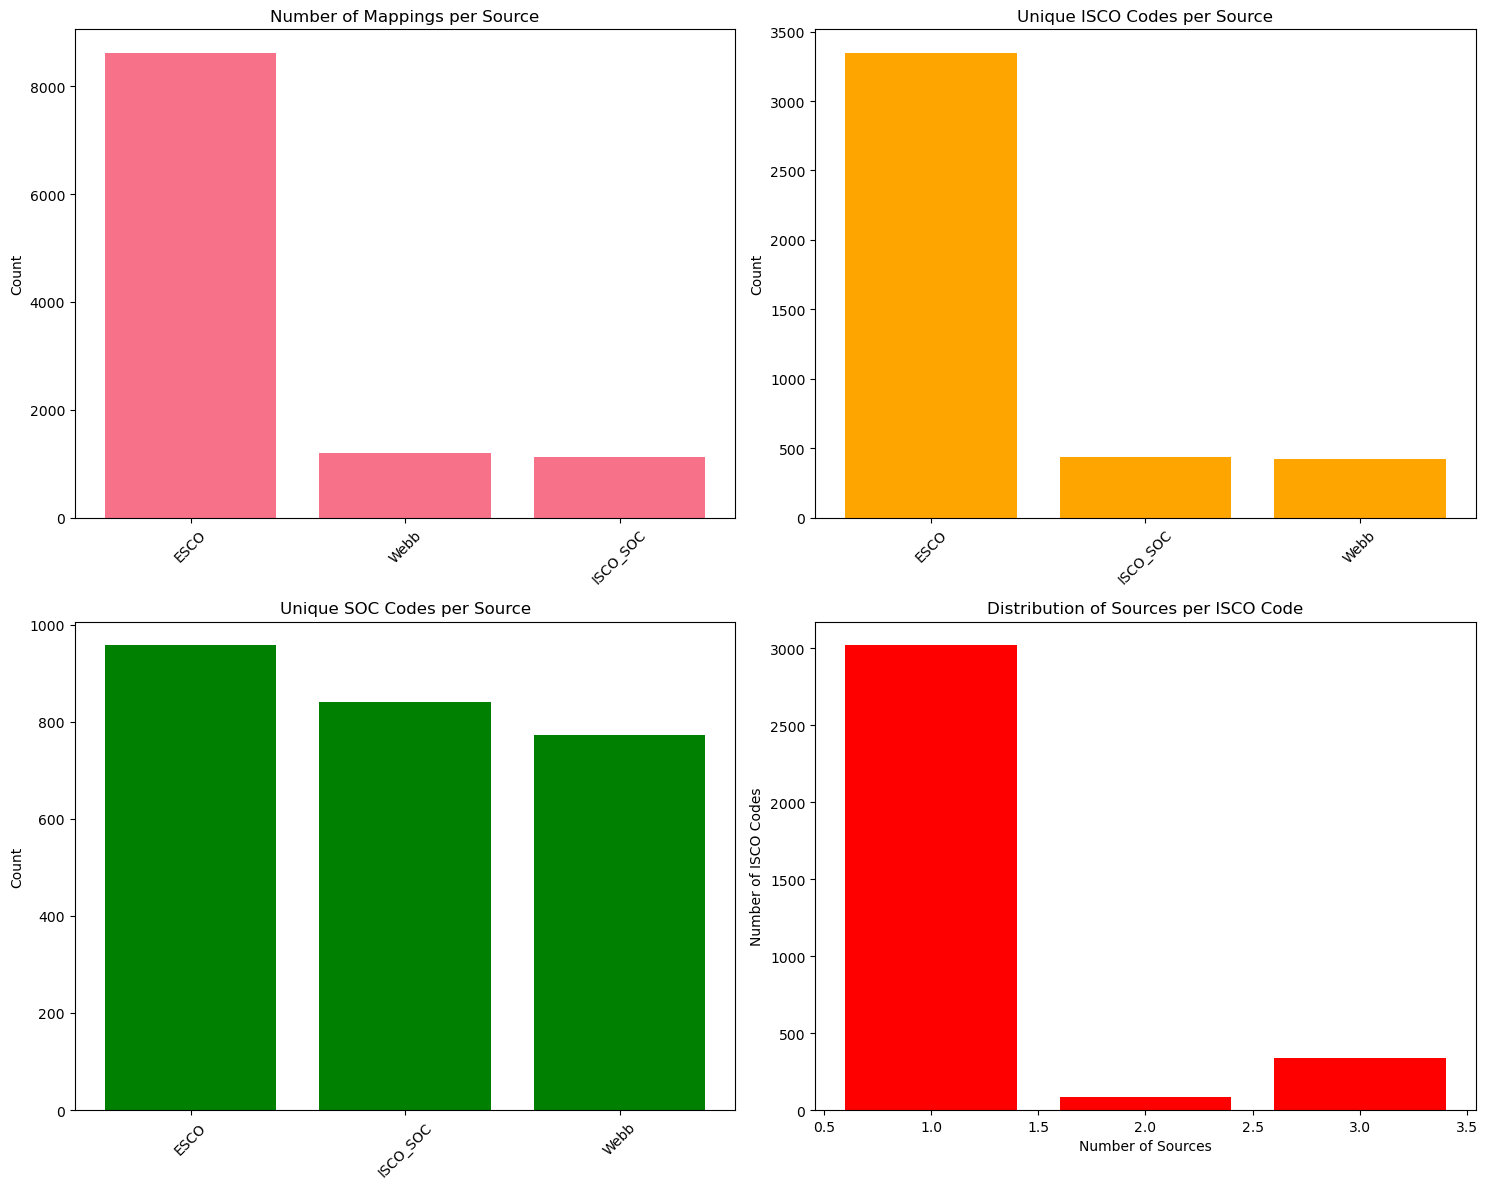


=== SUMMARY STATISTICS ===
Total mappings: 10949
Unique ISCO codes: 3445
Unique SOC codes: 1884
Sources: ['Webb', 'ISCO_SOC', 'ESCO']

=== PER-SOURCE STATISTICS ===
          Total_Mappings  Unique_ISCO  Unique_SOC
source                                           
ESCO                8627         3349         958
ISCO_SOC            1125          438         840
Webb                1197          422         772


In [27]:
if all_mappings is not None and not all_mappings.empty:
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Number of mappings per source
    source_counts = all_mappings['source'].value_counts()
    axes[0, 0].bar(source_counts.index, source_counts.values)
    axes[0, 0].set_title('Number of Mappings per Source')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Unique ISCO codes per source
    unique_isco_counts = all_mappings.groupby('source')['isco'].nunique()
    axes[0, 1].bar(unique_isco_counts.index, unique_isco_counts.values, color='orange')
    axes[0, 1].set_title('Unique ISCO Codes per Source')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Unique SOC codes per source
    unique_soc_counts = all_mappings.groupby('source')['soc'].nunique()
    axes[1, 0].bar(unique_soc_counts.index, unique_soc_counts.values, color='green')
    axes[1, 0].set_title('Unique SOC Codes per Source')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. Distribution of sources per ISCO code
    if len(multi_source_isco) > 0:
        isco_source_dist = isco_source_counts.value_counts().sort_index()
        axes[1, 1].bar(isco_source_dist.index, isco_source_dist.values, color='red')
        axes[1, 1].set_title('Distribution of Sources per ISCO Code')
        axes[1, 1].set_xlabel('Number of Sources')
        axes[1, 1].set_ylabel('Number of ISCO Codes')
    else:
        axes[1, 1].text(0.5, 0.5, 'No ISCO codes\nappear in multiple sources', 
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Distribution of Sources per ISCO Code')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n=== SUMMARY STATISTICS ===")
    print(f"Total mappings: {len(all_mappings)}")
    print(f"Unique ISCO codes: {all_mappings['isco'].nunique()}")
    print(f"Unique SOC codes: {all_mappings['soc'].nunique()}")
    print(f"Sources: {list(all_mappings['source'].unique())}")
    
    # Basic statistics per source
    print("\n=== PER-SOURCE STATISTICS ===")
    summary_stats = all_mappings.groupby('source').agg({
        'isco': ['count', 'nunique'],
        'soc': 'nunique'
    }).round(2)
    summary_stats.columns = ['Total_Mappings', 'Unique_ISCO', 'Unique_SOC']
    print(summary_stats)
    
else:
    print("Cannot create visualizations - no mappings available")

## 11. Export Results for Further Analysis

In [28]:
# Export the combined mappings and analysis results
if all_mappings is not None and not all_mappings.empty:
    # Save combined mappings
    output_path = Path('../Data/combined_isco_soc_mappings.csv')
    all_mappings.to_csv(output_path, index=False)
    print(f"Combined mappings saved to: {output_path}")
    
    # Save consistency analysis if available
    if 'consistency_df' in locals() and not consistency_df.empty:
        consistency_path = Path('../Data/isco_soc_mapping_consistency.csv')
        consistency_df.to_csv(consistency_path, index=False)
        print(f"Consistency analysis saved to: {consistency_path}")
    
    print("\nAnalysis complete! Key files created:")
    print(f"- Combined mappings: {output_path}")
    if 'consistency_df' in locals():
        print(f"- Consistency analysis: {consistency_path}")
else:
    print("No mappings to export")

Combined mappings saved to: ../Data/combined_isco_soc_mappings.csv
Consistency analysis saved to: ../Data/isco_soc_mapping_consistency.csv

Analysis complete! Key files created:
- Combined mappings: ../Data/combined_isco_soc_mappings.csv
- Consistency analysis: ../Data/isco_soc_mapping_consistency.csv


## Conclusions

This analysis compared ISCO to SOC mappings across three different crosswalk files. Key findings:

1. **Coverage**: Each source provides different coverage of ISCO codes
2. **Consistency**: Where ISCO codes appear in multiple sources, we analyzed mapping consistency
3. **Quality**: Different sources may have different granularity or mapping approaches

The combined dataset and consistency analysis have been saved for further use in the AI exposure analysis pipeline.